<div style="text-align: left; background-color:#4e4e4e; font-family: Trebuchet MS; color:white; padding: 12px; line-height:1.25;border-radius:1px; margin-bottom: 0em; text-align: center; font-size: 38px;border-style: solid;border-color: dark green;">Import Libraries </div>

In [1]:
!pip install --upgrade albumentations

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.1/43.1 kB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 332.3/332.3 kB 8.8 MB/s eta 0:00:00
  Attempting uninstall: albucore
    Found existing installation: albucore 0.0.23
    Uninstalling albucore-0.0.23:
      Successfully uninstalled albucore-0.0.23
  Attempting uninstall: albumentations
    Found existing installation: albumentations 2.0.4
    Uninstalling albumentations-2.0.4:
      Successfully uninstalled albumentations-2.0.4


In [ ]:
import os
import cv2
import random
import numpy as np
import pandas as pd
from tqdm import tqdm
import seaborn as sns
import albumentations as A
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

from keras.models import Model
from keras.optimizers import Adam
from keras.models import Sequential
from tensorflow.keras.applications import VGG16
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from keras.layers import Conv2D, MaxPooling2D, Dense, Activation, Input, GlobalAveragePooling2D

import warnings
warnings.filterwarnings("ignore")
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

<div style="text-align: left; background-color:#4e4e4e; font-family: Trebuchet MS; color:white; padding: 12px; line-height:1.25;border-radius:1px; margin-bottom: 0em; text-align: center; font-size: 38px;border-style: solid;border-color: dark green;">Data Loading </div>

In [3]:
ROOT_PATH = '/kaggle/input/breast-ultrasound-images-dataset/Dataset_BUSI_with_GT'
CATEGORIES = ['benign', 'malignant', 'normal']

images = []
labels = []

for category in CATEGORIES:
    folder_path = os.path.join(ROOT_PATH, category)
    for image_name in os.listdir(folder_path):
        if image_name.endswith('.png') and '_mask' not in image_name:
            image_path = os.path.join(folder_path, image_name)
            images.append(image_path)
            labels.append(category)
print(f'Numer of Images Samples: {len(images)}')
print(f'Numer of Labels Samples: {len(images)}')

Numer of Images Samples: 780
Numer of Labels Samples: 780


In [4]:
# Convert to Data Frame
data = {'Images': images, 'Labels': labels}
data = pd.DataFrame(data)
data.head()

,Images,Labels
0,/kaggle/input/breast-ultrasound-images-dataset...,benign
1,/kaggle/input/breast-ultrasound-images-dataset...,benign
2,/kaggle/input/breast-ultrasound-images-dataset...,benign
3,/kaggle/input/breast-ultrasound-images-dataset...,benign
4,/kaggle/input/breast-ultrasound-images-dataset...,benign


In [5]:
label2idx = {cat: idx for idx, cat in enumerate(CATEGORIES)}
label2idx

{'benign': 0, 'malignant': 1, 'normal': 2}

In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 780 entries, 0 to 779
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Images  780 non-null    object
 1   Labels  780 non-null    object
dtypes: object(2)
memory usage: 12.3+ KB


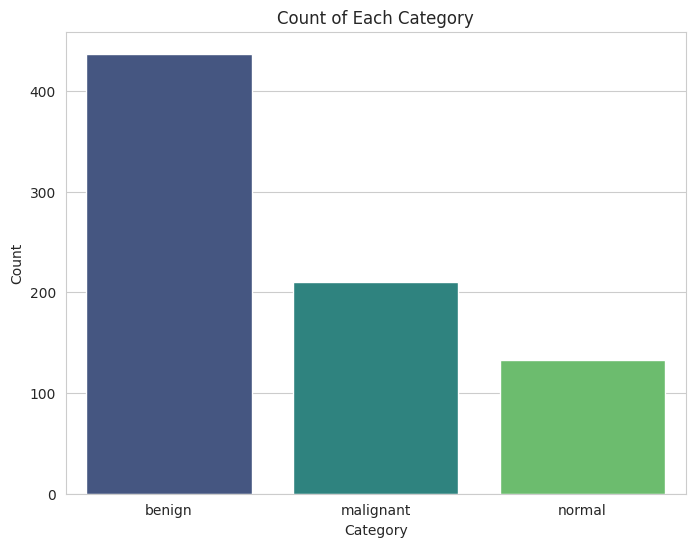

In [7]:
plt.figure(figsize=(8, 6))
sns.set_style("whitegrid")

ax = sns.countplot(data=data, x='Labels', palette='viridis')
plt.title("Count of Each Category")
plt.xlabel("Category")
plt.ylabel("Count")

plt.show()

- Data Imbalanced

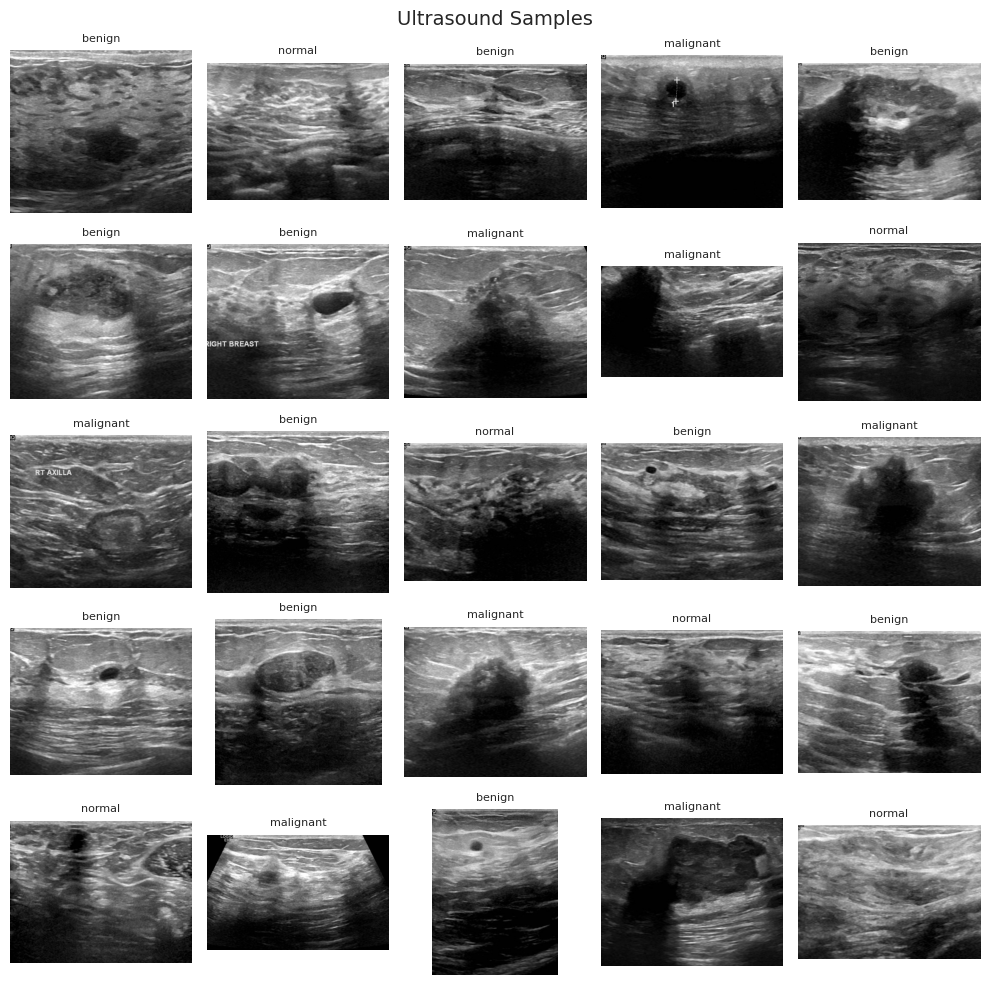

In [ ]:
plt.figure(figsize=(10, 10))
indices = random.sample(range(len(images)), 25)  

for i, idx in enumerate(indices):
    plt.subplot(5, 5, i + 1)
    plt.imshow(cv2.imread(images[idx]))
    plt.axis('off')
    plt.title(labels[idx], fontsize=8)

plt.suptitle('Ultrasound Samples', fontsize=14)
plt.tight_layout()
plt.show()


<div style="text-align: left; background-color:#4e4e4e; font-family: Trebuchet MS; color:white; padding: 12px; line-height:1.25;border-radius:1px; margin-bottom: 0em; text-align: center; font-size: 38px;border-style: solid;border-color: dark green;">Data Preprocessing</div>

In [9]:
train, test = train_test_split(data, test_size = 0.2, shuffle = True, stratify = data['Labels'],random_state = 42)

In [10]:
transform = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomRotate90(p=0.5),
])


In [11]:
all_images = []
all_labels = []

for category in CATEGORIES:
    original_images = train[train['Labels'] == category]['Images'].values.tolist()
    augmented_images = []

    print(f'Current Category: {category}')

    for img_path in tqdm(original_images):
        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        image = cv2.resize(image, (224, 224))
        augmented_images.append(image)
    
    while len(augmented_images) < 1000:
        img_path = random.choice(original_images)
        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        image = cv2.resize(image, (224, 224))
        
        augmented = transform(image=image)
        aug_img = augmented['image']
        aug_img = cv2.resize(aug_img, (224, 224))  
        augmented_images.append(aug_img)

    all_images.extend(augmented_images)
    all_labels.extend([label2idx[category]] * len(augmented_images))

all_images = np.array(all_images)
all_labels = np.array(all_labels)

print(f'Final dataset shape: {all_images.shape}')
print(f'Labels shape: {all_labels.shape}')


Current Category: benign


100%|██████████| 350/350 [00:05<00:00, 60.27it/s]


Current Category: malignant


100%|██████████| 168/168 [00:02<00:00, 63.60it/s]


Current Category: normal


100%|██████████| 106/106 [00:01<00:00, 56.60it/s]


Final dataset shape: (3000, 224, 224, 3)
Labels shape: (3000,)


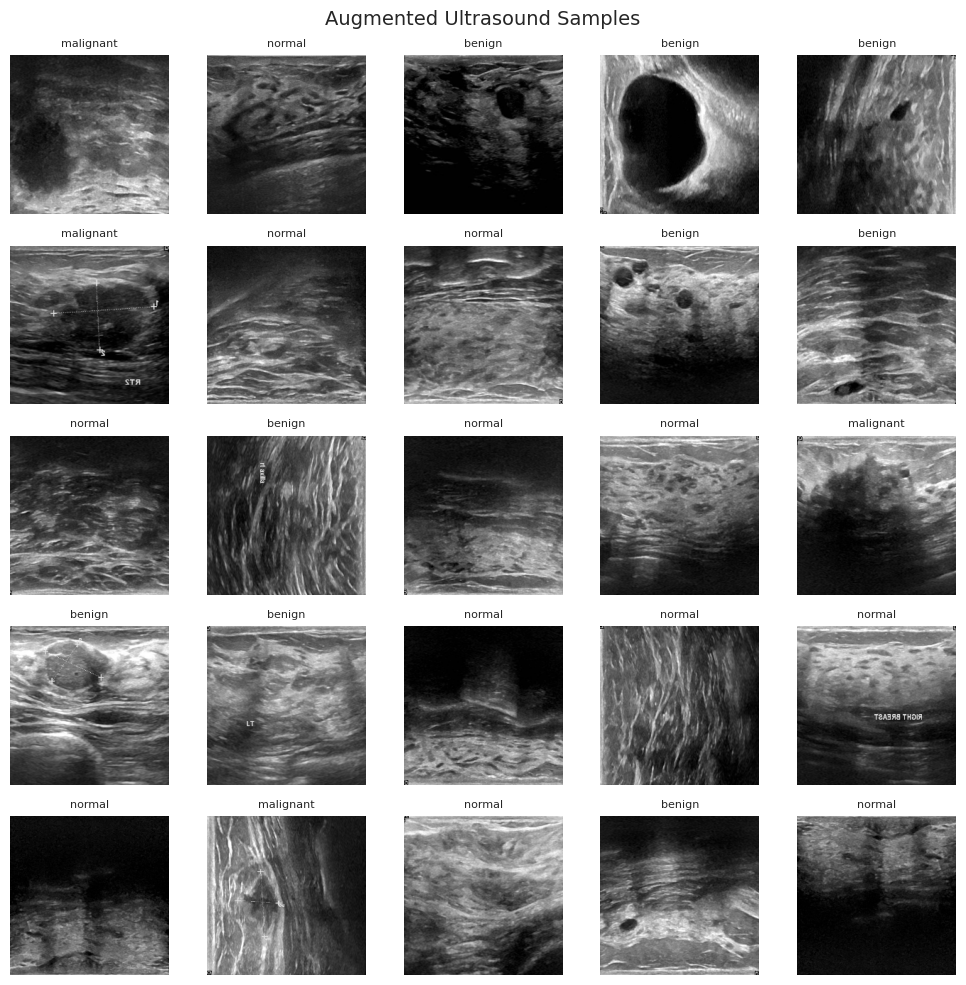

In [12]:
plt.figure(figsize=(10, 10))
indices = random.sample(range(len(all_images)), 25)  

for i, idx in enumerate(indices):
    plt.subplot(5, 5, i + 1)
    plt.imshow(all_images[idx])
    plt.axis('off')
    plt.title(CATEGORIES[all_labels[idx]], fontsize=8)

plt.suptitle('Augmented Ultrasound Samples', fontsize=14)
plt.tight_layout()
plt.show()


In [13]:
encoder = OneHotEncoder(sparse_output=False)
all_labels = encoder.fit_transform(all_labels.reshape((-1, 1)))

<div style="text-align: left; background-color:#4e4e4e; font-family: Trebuchet MS; color:white; padding: 12px; line-height:1.25;border-radius:1px; margin-bottom: 0em; text-align: center; font-size: 38px;border-style: solid;border-color: dark green;">Model Building</div>

In [14]:
def create_vgg16(input_shape):
    inputs = Input(shape=input_shape)
    base_model = VGG16(weights='imagenet', input_tensor=inputs, include_top=False)
    for layer in base_model.layers[:-4]:
        layer.trainable = False
    x = base_model.output
    x = GlobalAveragePooling2D()(x)
    x = Dense(128, activation='relu')(x)
    x = Dense(64, activation='relu')(x)
    outputs = Dense(3, activation='softmax')(x)
    model = Model(inputs=inputs, outputs=outputs)
    return model

input_shape = (224, 224, 3)
model = create_vgg16(input_shape)
model.compile(optimizer=Adam(learning_rate=0.0001), loss='categorical_crossentropy', metrics=['accuracy'])
history = model.fit(all_images, all_labels, validation_split = 0.2, epochs = 50)

I0000 00:00:1747097448.445662      19 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1747097448.446345      19 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/50


I0000 00:00:1747097454.778827      76 service.cc:148] XLA service 0x7d7608017430 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1747097454.779588      76 service.cc:156]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1747097454.779624      76 service.cc:156]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1747097455.219738      76 cuda_dnn.cc:529] Loaded cuDNN version 90300


 1/75 ━━━━━━━━━━━━━━━━━━━━ 20:35 17s/step - accuracy: 0.1250 - loss: 4.3725

I0000 00:00:1747097467.864423      76 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


75/75 ━━━━━━━━━━━━━━━━━━━━ 43s 356ms/step - accuracy: 0.5795 - loss: 1.0573 - val_accuracy: 0.5550 - val_loss: 1.1313
Epoch 2/50
75/75 ━━━━━━━━━━━━━━━━━━━━ 17s 232ms/step - accuracy: 0.8674 - loss: 0.3337 - val_accuracy: 0.9133 - val_loss: 0.2519
Epoch 3/50
75/75 ━━━━━━━━━━━━━━━━━━━━ 18s 243ms/step - accuracy: 0.9288 - loss: 0.2239 - val_accuracy: 0.9767 - val_loss: 0.0895
Epoch 4/50
75/75 ━━━━━━━━━━━━━━━━━━━━ 19s 256ms/step - accuracy: 0.9593 - loss: 0.1292 - val_accuracy: 0.9633 - val_loss: 0.2042
Epoch 5/50
75/75 ━━━━━━━━━━━━━━━━━━━━ 20s 265ms/step - accuracy: 0.9846 - loss: 0.0608 - val_accuracy: 0.8600 - val_loss: 0.4310
Epoch 6/50
75/75 ━━━━━━━━━━━━━━━━━━━━ 19s 253ms/step - accuracy: 0.9890 - loss: 0.0372 - val_accuracy: 0.9483 - val_loss: 0.1942
Epoch 7/50
75/75 ━━━━━━━━━━━━━━━━━━━━ 19s 248ms/step - accuracy: 0.9944 - loss: 0.0298 - val_accuracy: 0.9617 - val_loss: 0.1354
Epoch 8/50
75/75 ━━━━━━━━━━━━━━━━━━━━ 19s 252ms/step - accuracy: 0.9940 - loss: 0.0256 - val_accuracy: 0.973

In [15]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)             │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_conv1 (Conv2D)                │ (None, 224, 224, 64)        │           1,792 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_conv2 (Conv2D)                │ (None, 224, 224, 64)        │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_pool (MaxPooling2D)           │ (None, 112, 112, 64)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_conv1 (Conv2D)                │ (None, 112, 112, 128)       │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_conv2 (Conv2D)                │ (None, 112, 112, 128)       │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_pool (MaxPooling2D)           │ (None, 56, 56, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv1 (Conv2D)                │ (None, 56, 56, 256)         │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv2 (Conv2D)                │ (None, 56, 56, 256)         │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv3 (Conv2D)                │ (None, 56, 56, 256)         │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_pool (MaxPooling2D)           │ (None, 28, 28, 256)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv1 (Conv2D)                │ (None, 28, 28, 512)         │       1,180,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv2 (Conv2D)                │ (None, 28, 28, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv3 (Conv2D)                │ (None, 28, 28, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_pool (MaxPooling2D)           │ (None, 14, 14, 512)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv1 (Conv2D)                │ (None, 14, 14, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv2 (Conv2D)                │ (None, 14, 14, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv3 (Conv2D)                │ (None, 14, 14, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_pool (MaxPooling2D)           │ (None, 7, 7, 512)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d             │ (None, 512)                 │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │          65,6

 Total params: 29,095,883 (110.99 MB)

 Trainable params: 7,153,539 (27.29 MB)

 Non-trainable params: 7,635,264 (29.13 MB)

 Optimizer params: 14,307,080 (54.58 MB)

<div style="text-align: left; background-color:#4e4e4e; font-family: Trebuchet MS; color:white; padding: 12px; line-height:1.25;border-radius:1px; margin-bottom: 0em; text-align: center; font-size: 38px;border-style: solid;border-color: dark green;">Model Testing & Evaluation</div>

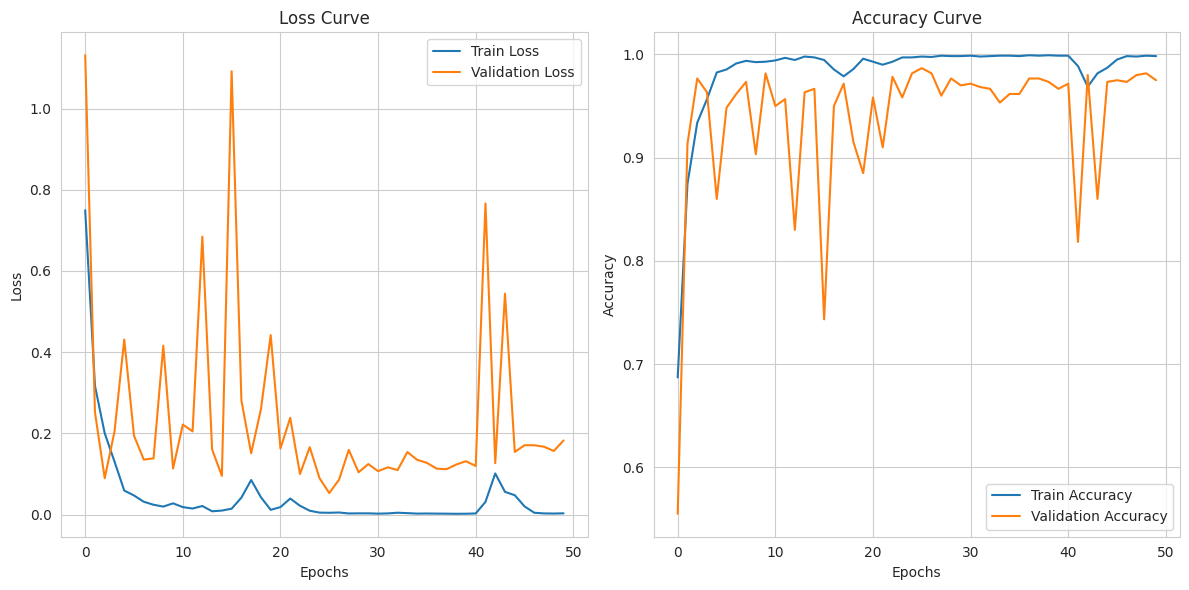

In [16]:
plt.figure(figsize=(12, 6))
# Loss
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss Curve')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
# Accuracy
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy Curve')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

In [17]:
test_images = []
test_labels = []

for idx, row in tqdm(test.iterrows(), total=len(test)):
    img_path = row['Images']
    label = row['Labels']
    
    image = cv2.imread(img_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    image = cv2.resize(image, (224, 224))

    test_images.append(image)
    test_labels.append(label2idx[label])

test_images = np.array(test_images)
test_labels = np.array(test_labels)

print(f'Test Images shape: {test_images.shape}')
print(f'Test Labels shape: {test_labels.shape}')

100%|██████████| 156/156 [00:02<00:00, 61.47it/s]

Test Images shape: (156, 224, 224, 3)
Test Labels shape: (156,)


In [18]:
predictions = np.argmax(model.predict(test_images)  , axis = 1)
report = classification_report(test_labels, predictions, target_names=CATEGORIES)
print(report)

5/5 ━━━━━━━━━━━━━━━━━━━━ 12s 3s/step
              precision    recall  f1-score   support

      benign       0.90      0.91      0.90        87
   malignant       0.83      0.83      0.83        42
      normal       0.85      0.81      0.83        27

    accuracy                           0.87       156
   macro avg       0.86      0.85      0.86       156
weighted avg       0.87      0.87      0.87       156



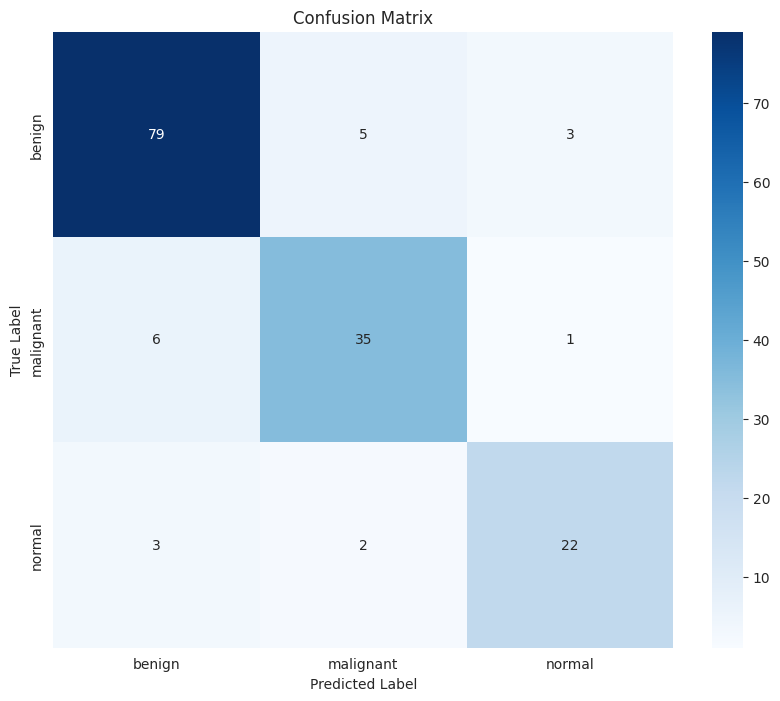

In [19]:
conf_matrix = confusion_matrix(test_labels, predictions)
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=CATEGORIES, yticklabels=CATEGORIES)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

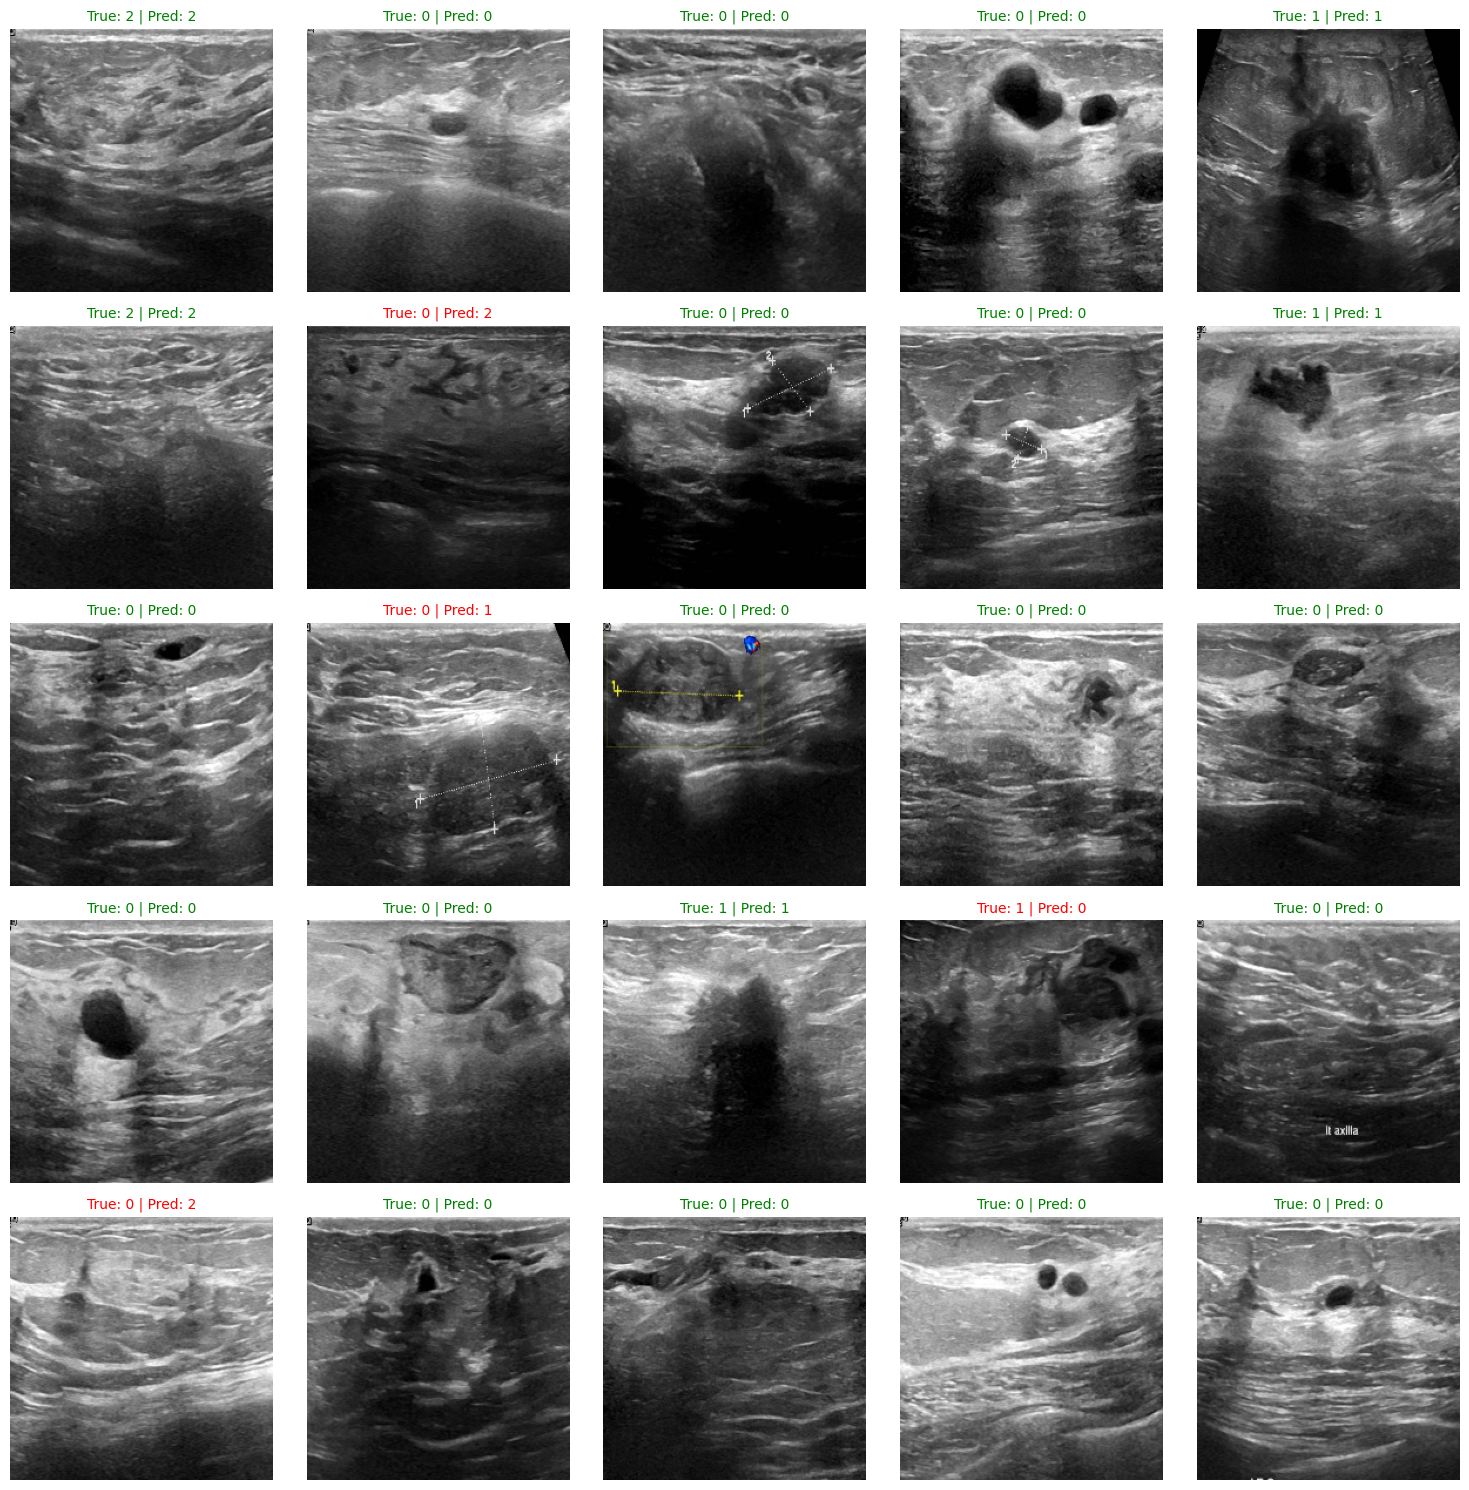

In [20]:
num_images = 25

plt.figure(figsize=(15, 15))

for i in range(num_images):
    plt.subplot(5, 5, i + 1)
    plt.imshow(test_images[i])
    plt.axis('off')
    
    true_label = test_labels[i]
    pred_label = predictions[i]
    
    title_color = 'green' if true_label == pred_label else 'red'
    plt.title(f"True: {true_label} | Pred: {pred_label}", color=title_color, fontsize=10)

plt.tight_layout()
plt.show()

<div style="text-align: left; background-color:#4e4e4e; font-family: Trebuchet MS; color:white; padding: 12px; line-height:1.25;border-radius:1px; margin-bottom: 0em; text-align: center; font-size: 38px;border-style: solid;border-color: dark green;">Save Model</div>

In [21]:
model.save('breast_classification_model.keras')